<span style="font-size:20px;"><b>Construccion de modelo Machine Learning</b></span>
<br>
<b>Fecha:</b> 24/08/2025
<br>
<b>Autor:</b> Lesly Alejandra Escobar Aguilar

<span style="font-size:20px;"><b>Librerias</b></span>

In [34]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
import matplotlib
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from datetime import date
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

<span style="font-size:20px;"><b>Análisis y Clustering</b></span>
<br>

In [5]:
#importacion del archivo csv
df = pd.read_csv('marketing_campaign.csv', delimiter=';', on_bad_lines='skip')

#Elimina espacios de las columnas
df.columns = df.columns.str.strip()

pd.set_option('display.max_rows', None) #Muesta todas las filas
pd.set_option('display.max_columns', None) #Muestra todas las columnas 

In [6]:
# Ordenamos por ID de menor a mayor
df = df.sort_values(by='ID', ascending=True)

# Eliminar espacios en los nombres de columnas
df.columns = df.columns.str.strip()

# Eliminar duplicados si los hubiera
df = df.drop_duplicates()

# Vista previa
pd.set_option('display.max_rows', 1000)
df.head(1000)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,1985,Graduation,Married,70951.0,0,0,4/5/2013,66,239,10,554,254,87,54,1,3,4,9,1,0,0,0,0,0,0,3,11,0
1,1,1961,Graduation,Single,57091.0,0,0,15/6/2014,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,0,3,11,1
2,9,1975,Master,Single,46098.0,1,1,18/8/2012,86,57,0,27,0,0,36,4,3,2,2,8,0,0,0,0,0,0,3,11,0
3,13,1947,PhD,Widow,25358.0,0,1,22/7/2013,57,19,0,5,0,0,8,2,1,0,3,6,0,0,0,0,0,0,3,11,0
4,17,1971,PhD,Married,60491.0,0,1,6/9/2013,81,637,47,237,12,19,76,4,6,11,7,5,0,0,0,0,0,0,3,11,0
5,20,1965,2n Cycle,Married,46891.0,0,1,1/9/2013,91,43,12,23,29,15,61,1,2,1,4,4,0,0,0,0,0,0,3,11,0
6,22,1976,Graduation,Divorced,46310.0,1,0,3/12/2012,99,185,2,88,15,5,14,2,6,1,5,8,0,0,0,0,0,0,3,11,0
7,24,1960,Master,Together,17144.0,1,1,15/2/2014,96,18,2,19,0,2,6,5,3,0,4,7,0,0,0,0,0,0,3,11,0
8,25,1958,Graduation,Married,65148.0,0,1,16/11/2012,9,460,35,422,33,12,153,2,6,6,7,4,0,0,0,0,0,0,3,11,0
9,35,1987,Graduation,Married,25545.0,1,0,8/9/2012,35,32,1,64,16,12,85,3,2,2,3,6,0,0,0,0,0,0,3,11,1


<span style="font-size:20px;"><b>Identificicacion de tipos de variables y manejo de datos faltantes</b></span>
<br>

In [33]:
#Seleccion de variables
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Columnas numéricas:", numericas)
print("Columnas categóricas:", categoricas)

#Primeras 1000 columnas
df_data = df.sample(1000, random_state=42)

df_data = df_data.dropna()

#Datos faltantes
# Numéricas → media
num_imputer = SimpleImputer(strategy='mean')
df_data[numericas] = num_imputer.fit_transform(df_data[numericas])

# Categóricas → moda
cat_imputer = SimpleImputer(strategy='most_frequent')
df_data[categoricas] = cat_imputer.fit_transform(df_data[categoricas])

Columnas numéricas: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
Columnas categóricas: ['Education', 'Marital_Status', 'Dt_Customer']


<span style="font-size:20px;"><b>Preprocesamiento y Kmeans</b></span>
<br>

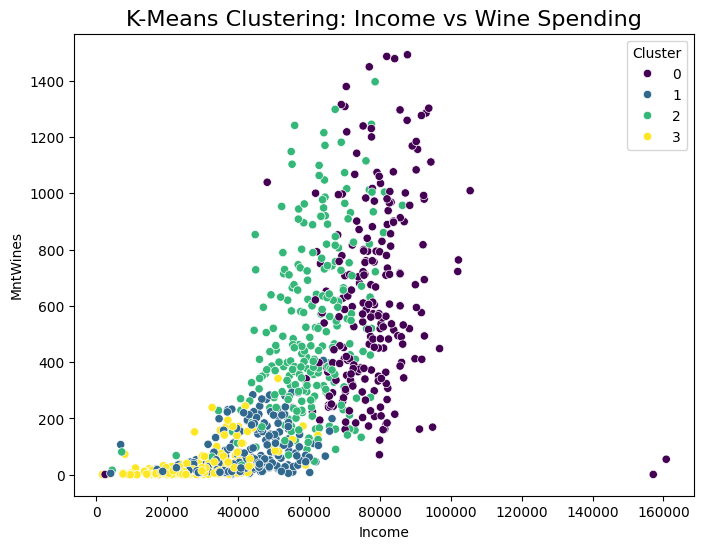

In [8]:
#Procesamiento y Kmeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(), categoricas)
    ]
)

# Definir K-Means
kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

# Ajustar modelo
kmeans_pipeline.fit(df_data)
df_data['Cluster'] = kmeans_pipeline.named_steps['kmeans'].labels_

#Cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_data, x='Income', y='MntWines', hue='Cluster', palette='viridis')
plt.title("K-Means Clustering: Income vs Wine Spending", fontsize=16)
plt.show()


<span style="font-size:20px;"><b>Análisis de Gastos</b></span>
<br>
<ul>
    <li>Educacion vs Gastos</li>
    <li>Rstado civil vs Gastos</li>
    <li>Cluster vs Gastos</li>
</ul>

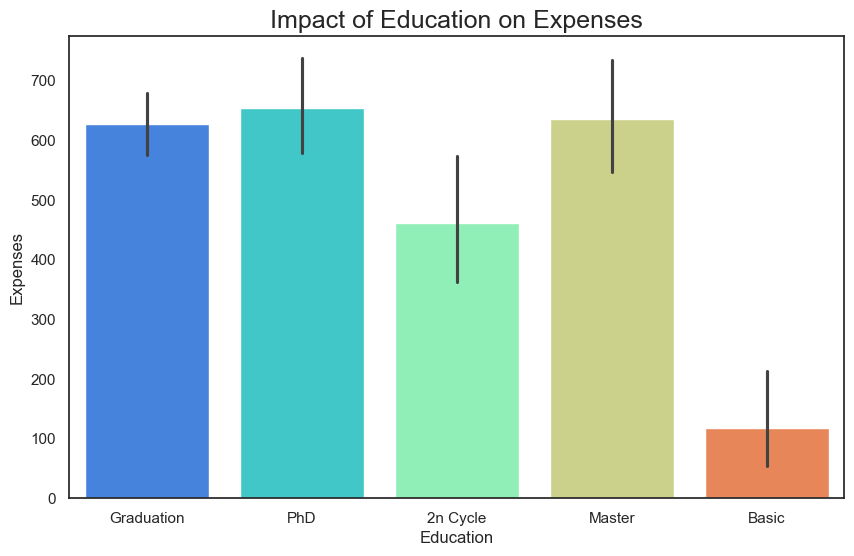

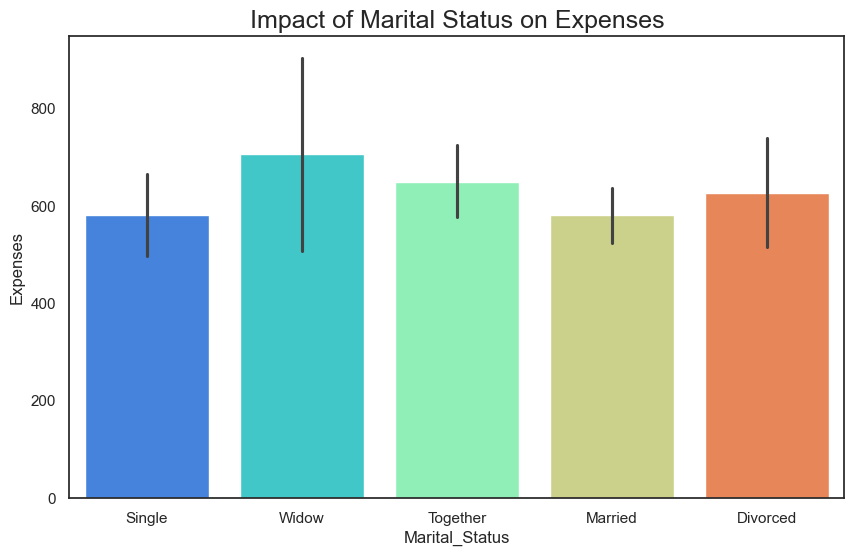

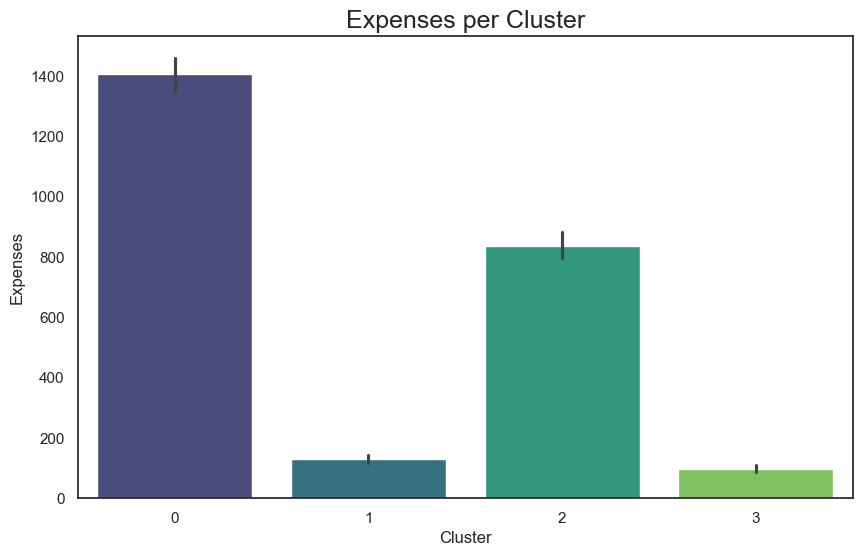

In [9]:
# Crear columna de gastos totales
df_data['Expenses'] = (df_data['MntWines'] + df_data['MntFruits'] + 
                         df_data['MntMeatProducts'] + df_data['MntFishProducts'] + 
                         df_data['MntSweetProducts'] + df_data['MntGoldProds'])
# Education vs Expenses
pd.crosstab(df_data['Education'], df_data['Expenses'], margins=True).style.background_gradient(cmap='Greys')
sns.set_theme(style="white")
plt.figure(figsize=(10,6))
plt.title("Impact of Education on Expenses", fontsize=18)
ax = sns.barplot(x="Education", y="Expenses", data=df_data, palette="rainbow")
plt.show()

#Marital_Status vs Expenses
pd.crosstab(df_data['Marital_Status'], df_data['Expenses'], margins=True).style.background_gradient(cmap='Greys')

plt.figure(figsize=(10,6))
sns.barplot(x="Marital_Status", y="Expenses", data=df_data, palette="rainbow")
plt.title("Impact of Marital Status on Expenses", fontsize=18)
plt.show()

#Cluster vs Expenses
plt.figure(figsize=(10,6))
sns.barplot(x="Cluster", y="Expenses", data=df_data, palette="viridis")
plt.title("Expenses per Cluster", fontsize=18)
plt.show()



<span style="font-size:20px;"><b>Cross-Validation </b></span>
<br>

In [25]:
#Definimos "x" y "y"
target = "Response"  
X = df_data.drop(columns=[target])
y = df_data[target]

num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

import sklearn
if sklearn.__version__ >= "1.2":
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", ohe, cat_features),
])

#Modelo
knn = KNeighborsClassifier(n_neighbors=10, weights="distance")
pipe = Pipeline([("preprocess", preprocess), ("model", knn)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs, f1s, aucs = [], [], []
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = pipe.predict(X.iloc[val_idx])
    probas = pipe.predict_proba(X.iloc[val_idx])[:,1]
    
    accs.append(accuracy_score(y.iloc[val_idx], preds))
    f1s.append(f1_score(y.iloc[val_idx], preds))
    aucs.append(roc_auc_score(y.iloc[val_idx], probas))
    
    print(f"Fold {fold} - Accuracy: {accs[-1]:.3f}, F1-Score: {f1s[-1]:.3f}, Area bajo la curva: {aucs[-1]:.3f}")

print(f"\nPromedio CV - Acc: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Promedio CV - F1 : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"Promedio CV - AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

Fold 1 - Accuracy: 0.848, F1-Score: 0.211, Area bajo la curva: 0.750
Fold 2 - Accuracy: 0.874, F1-Score: 0.444, Area bajo la curva: 0.876
Fold 3 - Accuracy: 0.863, F1-Score: 0.341, Area bajo la curva: 0.749
Fold 4 - Accuracy: 0.848, F1-Score: 0.211, Area bajo la curva: 0.735
Fold 5 - Accuracy: 0.909, F1-Score: 0.609, Area bajo la curva: 0.846

Promedio CV - Acc: 0.868 ± 0.022
Promedio CV - F1 : 0.363 ± 0.151
Promedio CV - AUC: 0.791 ± 0.058


<span style="font-size:20px;"><b>Graficos</b></span>
<br>

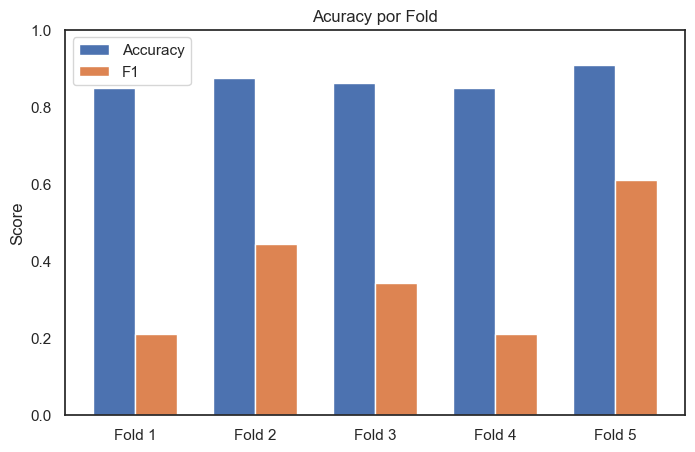

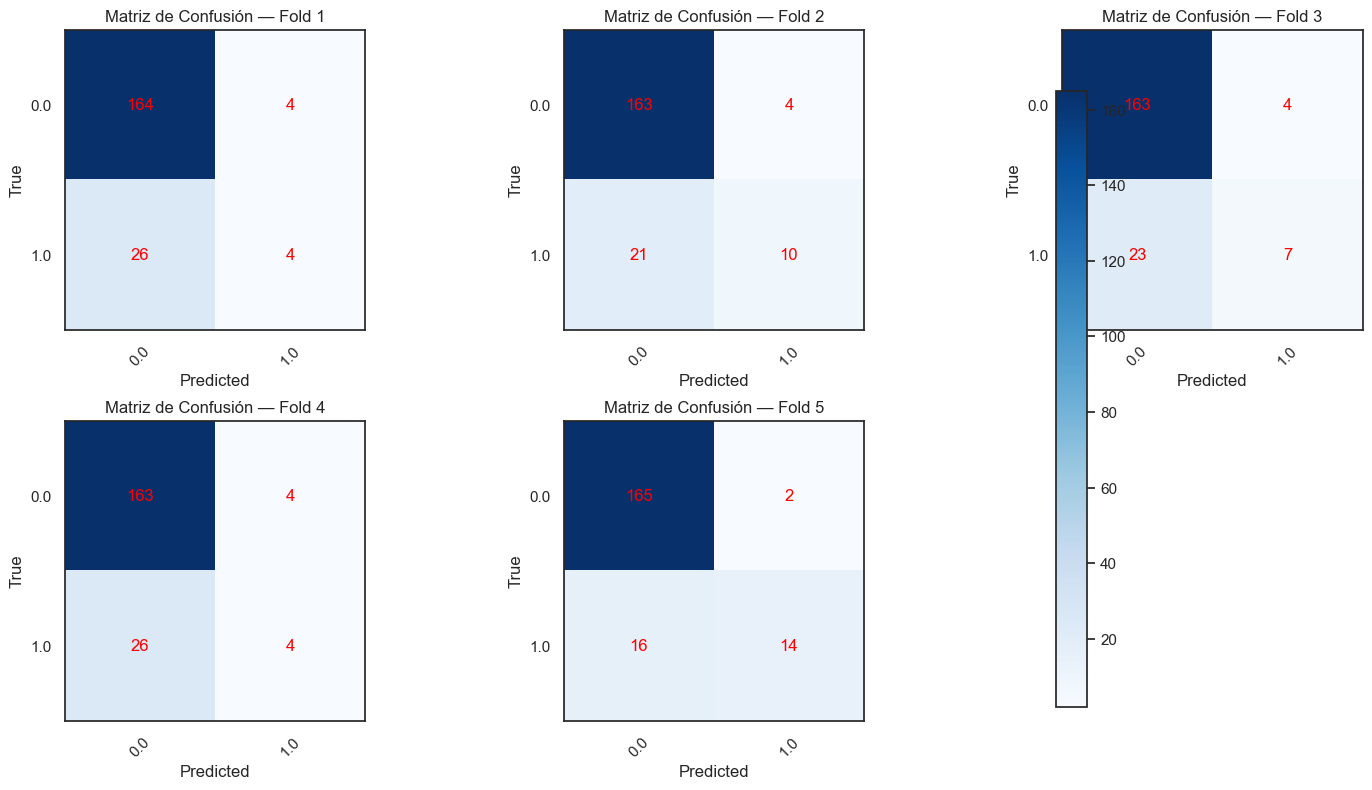

In [26]:
#Grafico de barras
fold_ids = np.arange(1, len(accs)+1)
plt.figure(figsize=(8,5))
width = 0.35
plt.bar(fold_ids - width/2, accs, width, label="Accuracy")
plt.bar(fold_ids + width/2, f1s,  width, label="F1")
plt.xticks(fold_ids, [f"Fold {i}" for i in fold_ids])
plt.ylabel("Score")
plt.title("Acuracy por Fold")
plt.legend()
plt.ylim(0, 1.0)
plt.show()

#Matriz de confusion
n = len(conf_matrices)
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.ravel()
for i, cm in enumerate(conf_matrices):
    ax = axes[i]
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(f"Matriz de Confusión — Fold {i+1}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(class_order))); ax.set_yticks(range(len(class_order)))
    ax.set_xticklabels(class_order, rotation=45); ax.set_yticklabels(class_order)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center", color="red")
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])
fig.colorbar(im, ax=axes[:n])  
plt.tight_layout()
plt.show()

<span style="font-size:20px;"><b>Arbol de decision</b></span>
<br>

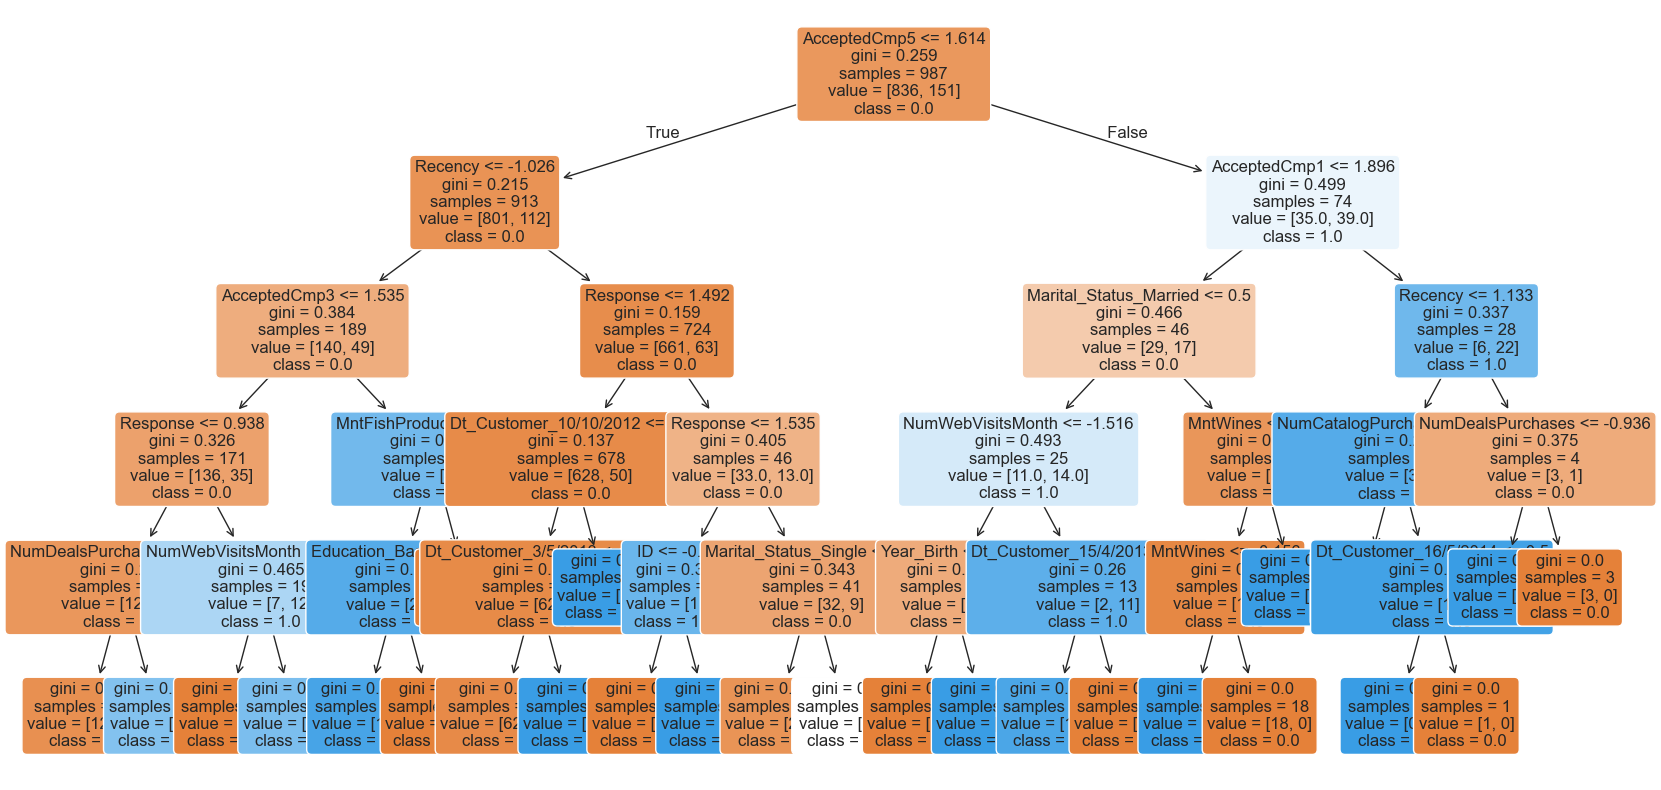

In [36]:
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
pipe = Pipeline([("preprocess", preprocess), ("model", dtree)])
pipe.fit(X, y)
plt.figure(figsize=(20,10))
plot_tree(
    pipe.named_steps['model'],
    feature_names=numericas + list(pipe.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out()),
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()

<span style="font-size:20px;"><b>Conclusiones</b></span>
<br>

<ul>
    <li>El accuray por fold se encuentra muy alta(≈0.85–0.9), esto indica que el modelo predice correctamente la mayoría de los casos.</li>
    <li>El F1-score varía entre 0.2 y 0.6. Lo que significa que hay un desbalance en las clases</li>
    <li>Segun podemos ver existen mas verdaderos negativos que verdaderos positivos, teniendo los verdaderos negativos un total de 164</li>
    <li>El fold 5 muestra mejores verdaderos positivos con un total de 14, pero sigue siendo baja a comparacion de los verdaderos negativos</li>
</ul>